<a href="https://colab.research.google.com/github/gyanellaagreda-bd/MINERIA-DE-DATOS---2026-1/blob/main/AGREDA_LAB_S04_MDD_PSAYAN_2026_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 LABORATORIO N° 04 — Minería de Datos

## Preparación de Datos (Fase 3 de CRISP-DM)

| | |
|:---|:---|
| **Curso** | Minería de Datos — C64893 |
| **Semana** | 4 |
| **Docente** | Pilar Rocío Sayán Mejía |
| **Institución** | TECSUP — Pasión por la Tecnología |
| **Semestre** | 2026-I |

---

## 📋 Instrucciones generales

- Ejecuta **todas** las celdas de código en orden.
- Responde las preguntas en las celdas de texto (Markdown) asignadas.
- Al finalizar, descarga el notebook (`.ipynb`) con todas las celdas ejecutadas.


## 📚 Referencias

- Gironés Roig, J. et al. (2017). *Minería de datos: modelos y algoritmos*. Editorial UOC. Cap. 3.
- Géron, A. (2022). *Hands-On Machine Learning* (3.ª ed.). O'Reilly Media. Cap. 2.
- Ilyas, I. F. y Chu, X. (2019). *Cleaning Data for Data Science*. ACM.
- Müller, A. C. y Guido, S. (2016). *Introduction to Machine Learning with Python*. O'Reilly Media. Cap. 3.

---
# ACTIVIDAD 1: Revisión de Conceptos — Preparación de Datos

| N° | Concepto | Definición |
|----|----------|------------|
| 1 | ¿Por qué es importante la preparación de datos en CRISP-DM? | Garantiza que los datos sean consistentes, completos y útiles antes del modelado. Datos de baja calidad producen modelos defectuosos sin importar el algoritmo (principio GIGO). Es la fase que más tiempo consume y mayor impacto tiene en el rendimiento final. |
| 2 | Principio GIGO (Garbage In, Garbage Out) | Si los datos de entrada son incorrectos, incompletos o sesgados, el modelo producirá resultados igualmente defectuosos. La calidad del modelo depende directamente de la calidad de los datos. |
| 3 | Imputación de valores nulos | Técnica para reemplazar valores faltantes con estimaciones: media o mediana (variables numéricas), moda (categóricas), o métodos avanzados como KNN o regresión. Evita perder registros completos por datos faltantes parciales. |
| 4 | Detección de outliers con IQR | Valores fuera del rango [Q1 − 1.5·IQR, Q3 + 1.5·IQR] se consideran atípicos. IQR = Q3 − Q1. Es un método robusto que no asume distribución normal. |
| 5 | Normalización Min-Max vs Estandarización Z-score | Min-Max escala valores al rango [0, 1]; sensible a outliers. Z-score transforma a media=0 y desviación estándar=1; más robusto ante valores extremos. Se usan según el algoritmo y la distribución de los datos. |
| 6 | One-Hot Encoding | Convierte variables categóricas en columnas binarias (0/1), una por cada categoría. Permite que los algoritmos procesen variables no numéricas. Se usa drop_first=True para evitar multicolinealidad. |
| 7 | Feature Engineering | Creación de nuevas variables a partir de las existentes para capturar relaciones ocultas y mejorar el poder predictivo del modelo. Requiere conocimiento del negocio y del dominio del problema. |
| 8 | Discretización | Transformar una variable continua en intervalos o rangos discretos (ej. tenure → Nuevo/Corto/Medio/Largo). Útil para capturar relaciones no lineales y mejorar la interpretabilidad. |
| 9 | Selección de atributos (métodos de filtro) | Técnicas que evalúan la relevancia de cada variable respecto a la variable objetivo sin entrenar el modelo (ej. información mutua, chi cuadrado, correlación). Reduce ruido y dimensionalidad. |
| 10 | PCA (Análisis de Componentes Principales) | Técnica de reducción de dimensionalidad que proyecta los datos en nuevos ejes (componentes) que maximizan la varianza explicada. Elimina redundancia entre variables correlacionadas. |
| 11 | ¿Qué es Data Leakage? | Ocurre cuando información del conjunto de prueba o del futuro contamina el entrenamiento, generando métricas infladas irreales. Se evita dividiendo train/test antes de cualquier transformación y ajustando los transformadores solo con datos de entrenamiento. |
| 12 | Pipeline de preparación en scikit-learn | Objeto que encadena transformaciones y modelo en un flujo reproducible y ordenado. Garantiza que cada paso se aplique correctamente en entrenamiento y predicción, evitando data leakage y errores manuales. |

---
# ACTIVIDAD 2: Pipeline de Preparación de Datos

*Ref: Gironés Roig, J. et al. (2017). Minería de datos. Editorial UOC. Cap. 3.*

## 🔷 Paso 1: Carga del dataset y detección de problemas

*Ref: Ilyas, I. F. y Chu, X. (2019). Cleaning Data for Data Science. ACM.*

**¿Qué hacemos?** Cargamos el dataset *Telco Customer Churn* e inspeccionamos su estructura:
dimensiones, tipos de datos, valores nulos y duplicados.

**¿Por qué?** Conocer el estado real de los datos antes de cualquier transformación es
indispensable en CRISP-DM. Esta auditoría inicial guía todas las decisiones de limpieza.

**Impacto:** Detectar problemas desde el inicio evita que los errores se propaguen silenciosamente
a etapas posteriores del pipeline.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuracion de visualizacion
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Cargar dataset
url = ('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/'
       'master/data/Telco-Customer-Churn.csv')
df = pd.read_csv(url)

print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
print('\nTIPOS DE DATOS:')
print(df.dtypes.to_string())
print('\nVALORES NULOS POR COLUMNA:')
print(df.isnull().sum().to_string())
print(f'\nDUPLICADOS: {df.duplicated().sum()} filas')
print('\nNota: TotalCharges aparece como object (texto).')
print('Contiene espacios en blanco que representan valores faltantes.')
print('Se corregira en el Paso 2.')

Dataset cargado: 7043 filas x 21 columnas

TIPOS DE DATOS:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object

VALORES NULOS POR COLUMNA:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies  

## 🔷 Paso 2: Limpieza de datos y corrección de TotalCharges

*Ref: Ilyas, I. F. y Chu, X. (2019). Cleaning Data for Data Science. ACM.*

**¿Qué hacemos?** Corregimos `TotalCharges` (almacenada como texto por espacios en blanco `" "`)
y eliminamos `customerID` que no tiene valor predictivo.

**¿Por qué?** Los espacios en blanco representan clientes con `tenure = 0` (sin historial de
facturación). Si no los convertimos, el pipeline numérico fallará. Usamos asignación directa
**sin `inplace=True`** para evitar `SettingWithCopyWarning` de pandas.

**Impacto:** Una limpieza correcta garantiza que los tipos de datos sean coherentes con su
naturaleza, condición previa para que el pipeline funcione sin errores.

In [ ]:
# Paso 1: eliminar espacios en blanco " hola " --> "hola  ""
df['TotalCharges'] = df['TotalCharges'].str.strip()

# Paso 2: reemplazar cadenas vacias por NaN
df['TotalCharges'] = df['TotalCharges'].replace('', np.nan)

# Paso 3: convertir a numerico (sin inplace=True, sin warnings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

nulos_tc = df['TotalCharges'].isnull().sum()
print(f'TotalCharges convertido a: {df["TotalCharges"].dtype}')
print(f'Valores nulos generados: {nulos_tc}')

# Analizar los registros con NaN en TotalCharges
clientes_nulos = df[df['TotalCharges'].isnull()]
print(f'\nClientes con TotalCharges nulo: {len(clientes_nulos)}')
print(f'Todos tienen tenure = 0: {(clientes_nulos["tenure"] == 0).all()}')
print('Son clientes nuevos sin cargos acumulados.')
print('Estos NaN seran imputados con la MEDIANA en el pipeline (Paso 8).')

# Eliminar columna identificadora
df = df.drop(columns=['customerID'])
print(f'\ncustomerID eliminado (sin valor predictivo)')
print(f'Dimensiones actuales: {df.shape[0]} filas x {df.shape[1]} columnas')

TotalCharges convertido a: float64
Valores nulos generados: 11

Clientes con TotalCharges nulo: 11
Todos tienen tenure = 0: True
Son clientes nuevos sin cargos acumulados.
Estos NaN seran imputados con la MEDIANA en el pipeline (Paso 8).

customerID eliminado (sin valor predictivo)
Dimensiones actuales: 7043 filas x 20 columnas


### ✏️ Pregunta 1

**¿Cuántos valores nulos tiene la variable `TotalCharges` después de la conversión?
¿Qué método de imputación usarías y por qué?**

> **Respuesta:**
TotalCharges tiene **11 valores nulos** tras la conversión. Corresponden a clientes con tenure=0 (sin historial de facturación). Se usa **imputación por mediana** porque la distribución de TotalCharges es sesgada (muchos clientes nuevos con cargos bajos), y la mediana es robusta ante esa asimetría, a diferencia de la media que sobreestimaría el valor imputado.

## 🔷 Paso 3: Análisis exploratorio y balance de la variable objetivo

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 2.*

**¿Qué hacemos?** Realizamos un análisis descriptivo básico y analizamos la distribución
de la variable objetivo `Churn` para detectar desbalance entre clases.

**¿Por qué?** El análisis del balance de clases es **obligatorio** antes de modelar.
Un modelo que prediga siempre "No Churn" podría tener ~73% de accuracy sin aprender nada útil,
pero fallaría completamente en detectar a los clientes en riesgo.

**Impacto:** Este análisis informa las decisiones de modelado. **En esta etapa solo observamos
y documentamos; no modificamos la distribución original.**

> ⚠️ **¿Por qué NO aplicamos técnicas de balanceo aquí?**
> Técnicas como SMOTE, oversampling o undersampling deben aplicarse **exclusivamente** sobre
> los datos de entrenamiento, **después del split**, para no contaminar el test set con datos
> sintéticos. El balanceo corresponde a la **Fase de Modelado (CRISP-DM Fase 4)**.

ESTADISTICAS DESCRIPTIVAS (variables numericas):
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7032.00
mean     32.37           64.76       2283.30
std      24.56           30.09       2266.77
min       0.00           18.25         18.80
25%       9.00           35.50        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.85       3794.74
max      72.00          118.75       8684.80

DISTRIBUCION DE LA VARIABLE OBJETIVO — Churn:
  No: 5,174 clientes (73.5%)
  Yes: 1,869 clientes (26.5%)
  Ratio desbalance (No:Yes): 2.8:1


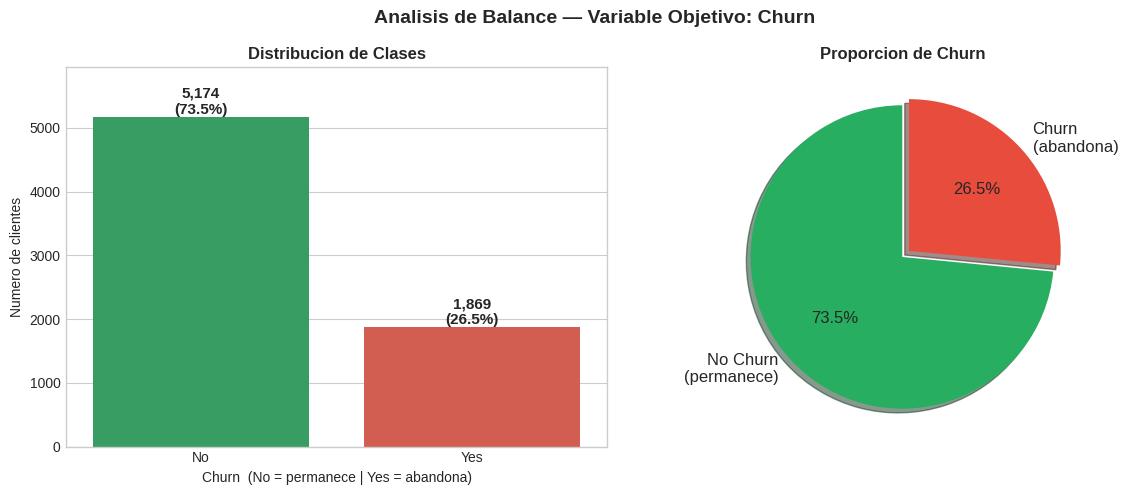


CONCLUSION:
  El dataset tiene desbalance moderado: 73.5% No Churn / 26.5% Churn
  Este desbalance es tipico en telecomunicaciones (tasas de churn: 15-35% anual).
  Se deben usar metricas como Recall, F1-Score y AUC-ROC en el modelado.


In [ ]:
# Estadisticas descriptivas
print('ESTADISTICAS DESCRIPTIVAS (variables numericas):')
vars_eda = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(df[vars_eda].describe().round(2).to_string())

# Distribucion de la variable objetivo
print('\nDISTRIBUCION DE LA VARIABLE OBJETIVO — Churn:')
dist = df['Churn'].value_counts()
pct  = df['Churn'].value_counts(normalize=True) * 100
for c in ['No', 'Yes']:
    print(f'  {c}: {dist[c]:,} clientes ({pct[c]:.1f}%)')
print(f'  Ratio desbalance (No:Yes): {pct["No"]/pct["Yes"]:.1f}:1')

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Analisis de Balance — Variable Objetivo: Churn',
             fontsize=14, fontweight='bold')

# Countplot
colores_churn = {'No': '#27ae60', 'Yes': '#e74c3c'}
sns.countplot(data=df, x='Churn', ax=axes[0], palette=colores_churn)
axes[0].set_title('Distribucion de Clases', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Churn  (No = permanece | Yes = abandona)')
axes[0].set_ylabel('Numero de clientes')
axes[0].set_ylim(0, dist['No'] * 1.15)
for bar in axes[0].patches:
    h = bar.get_height()
    axes[0].annotate(f'{int(h):,}\n({h/len(df)*100:.1f}%)',
                     (bar.get_x() + bar.get_width()/2., h),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
sizes = [dist['No'], dist['Yes']]
labels = ['No Churn\n(permanece)', 'Churn\n(abandona)']
axes[1].pie(sizes, labels=labels, colors=['#27ae60','#e74c3c'],
            autopct='%1.1f%%', startangle=90, explode=(0, 0.06),
            textprops={'fontsize': 12}, shadow=True)
axes[1].set_title('Proporcion de Churn', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCONCLUSION:')
print(f'  El dataset tiene desbalance moderado: {pct["No"]:.1f}% No Churn / {pct["Yes"]:.1f}% Churn')
print('  Este desbalance es tipico en telecomunicaciones (tasas de churn: 15-35% anual).')
print('  Se deben usar metricas como Recall, F1-Score y AUC-ROC en el modelado.')

### 📌 Interpretación del balance de clases

El dataset presenta un **desbalance moderado** (~74% No Churn / ~26% Churn).

**¿Por qué el desbalance es común en problemas de churn?**
En negocios reales de telecomunicaciones, la tasa de abandono anual oscila entre 15% y 35%.
La mayoría de los clientes mantiene su contrato activo en cualquier período de observación,
por lo que la clase "Churn = Yes" es naturalmente minoritaria. Este fenómeno es intrínseco
a los problemas de retención de clientes.

**Implicaciones para el modelado:**
- Un clasificador que prediga siempre "No Churn" tendría ~74% de *accuracy* sin aprender nada.
- Se deben preferir métricas: **Recall**, **F1-Score** y **AUC-ROC**.
- El objetivo es maximizar la detección de clientes en riesgo (clase minoritaria).

## 🔷 Paso 4: Variable objetivo y Feature Engineering

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 2.*

**¿Qué hacemos?**
1. Definimos `Churn_num` como variable objetivo numérica (1 = abandona, 0 = permanece),
   usada de forma **consistente** en todo el notebook.
2. Creamos nuevas variables derivadas con conocimiento del dominio del negocio.

**¿Por qué el Feature Engineering se hace antes del split?**

El Feature Engineering se realiza antes del train/test split porque las variables creadas son transformaciones determinísticas (reglas fijas que no dependen de estadísticas del dataset, como medias o desviaciones).

Estas transformaciones no generan Data Leakage, ya que no utilizan información del conjunto de test para su cálculo.

Sin embargo, en entornos productivos o pipelines más robustos, estas transformaciones pueden integrarse dentro del Pipeline para garantizar consistencia y reproducibilidad en nuevos datos.

In [ ]:
# Variable objetivo — nombre UNICO y CONSISTENTE en todo el notebook
df['Churn_num'] = df['Churn'].map({'Yes': 1, 'No': 0})
print('Variable objetivo: Churn_num (1 = Churn, 0 = No Churn)')
print(f'  1 (Churn):    {df["Churn_num"].sum():,} clientes')
print(f'  0 (No Churn): {(df["Churn_num"]==0).sum():,} clientes')

print('\nCREANDO NUEVAS VARIABLES (Feature Engineering):')

# 1. tenure_group — Segmento por antiguedad del cliente
# Valor de negocio: La relacion entre antiguedad y churn NO es lineal.
# Clientes "Nuevo" (0-12 meses) evaluan si el servicio vale la pena -> mayor riesgo.
# Clientes "Largo" (>48 meses) tienen mayor costo de cambio -> menor riesgo de churn.
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['Nuevo', 'Corto', 'Medio', 'Largo'],
    include_lowest=True
)
df['tenure_group'] = df['tenure_group'].astype(str)

print('\n1. tenure_group (segmento por antiguedad):')
tg = df.groupby('tenure_group')['Churn_num'].agg(['count','mean'])
tg.columns = ['Clientes', 'Tasa Churn']
tg['Tasa Churn'] = tg['Tasa Churn'].map('{:.1%}'.format)
print(tg.to_string())

# 2. num_servicios — Total de servicios contratados
# Valor de negocio: Clientes con mas servicios tienen mayor "switching cost"
# (costo de migrar a otro proveedor). Pocos servicios = menor engagement -> mayor churn.
df['num_servicios'] = (
    (df['PhoneService']     == 'Yes').astype(int) +
    (df['InternetService']  != 'No').astype(int)  +
    (df['OnlineSecurity']   == 'Yes').astype(int) +
    (df['TechSupport']      == 'Yes').astype(int) +
    (df['StreamingTV']      == 'Yes').astype(int) +
    (df['OnlineBackup']     == 'Yes').astype(int) +
    (df['DeviceProtection'] == 'Yes').astype(int) +
    (df['StreamingMovies']  == 'Yes').astype(int)
)
print(f'\n2. num_servicios (servicios contratados):')
print(df['num_servicios'].value_counts().sort_index().to_string())

# 3. cargo_por_mes — Costo mensual promedio acumulado
# Valor de negocio: Si cargo_por_mes >> MonthlyCharges, el cliente pago mas
# en el pasado (upgrades o cargos adicionales). Una subida percibida en el precio
# es un factor clave de insatisfaccion y abandono.
df['cargo_por_mes'] = df['TotalCharges'] / (df['tenure'] + 1)
print(f'\n3. cargo_por_mes (costo promedio mensual historico):')
print(df['cargo_por_mes'].describe().round(2).to_string())

print('\nMUESTRA DE LAS NUEVAS VARIABLES:')
cols_m = ['tenure', 'tenure_group', 'num_servicios', 'MonthlyCharges', 'cargo_por_mes']
print(df[cols_m].head(10).to_string())

Variable objetivo: Churn_num (1 = Churn, 0 = No Churn)
  1 (Churn):    1,869 clientes
  0 (No Churn): 5,174 clientes

CREANDO NUEVAS VARIABLES (Feature Engineering):

1. tenure_group (segmento por antiguedad):
              Clientes Tasa Churn
tenure_group                     
Corto             1024      28.7%
Largo             2239       9.5%
Medio             1594      20.4%
Nuevo             2186      47.4%

2. num_servicios (servicios contratados):
num_servicios
1    1606
2     727
3     996
4    1041
5    1062
6     827
7     525
8     259

3. cargo_por_mes (costo promedio mensual historico):
count    7032.00
mean       59.08
std        30.51
min         9.18
25%        26.23
50%        61.07
75%        84.88
max       118.97

MUESTRA DE LAS NUEVAS VARIABLES:
   tenure tenure_group  num_servicios  MonthlyCharges  cargo_por_mes
0       1        Nuevo              2           29.85      14.925000
1      34        Medio              4           56.95      53.985714
2       2        N

### ✏️ Pregunta 5

**¿Por qué es útil crear la variable `num_servicios`? ¿Qué información aporta al modelo de churn?**

>**Respuesta:**
Consolida en una sola variable cuántos servicios tiene contratados el cliente. Mayor número de servicios implica mayor *switching cost* (costo de migrar a otro proveedor) y mayor engagement, por lo que el cliente es menos propenso a cancelar. Simplifica la información de 8 variables binarias en una escala ordinal, facilitando que el modelo capture esa relación directamente.

## 🔷 Paso 5: Separación en X/y y División Train/Test

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 2.*

---

### ⛔ CORRECCIÓN CRÍTICA: Eliminación de Data Leakage

**¿Qué es Data Leakage?**
El *Data Leakage* ocurre cuando información del conjunto de **prueba** contamina el proceso
de **entrenamiento**. Esto produce modelos con métricas artificialmente altas que fallan
en producción con datos reales.

**¿Cómo ocurría en la versión original?**

```python
# VERSION ORIGINAL — CON DATA LEAKAGE (INCORRECTO)
minmax = MinMaxScaler()
df_minmax = pd.DataFrame(minmax.fit_transform(df[vars_numericas]))  # usa TODO el dataset

zscore = StandardScaler()
df_zscore = pd.DataFrame(zscore.fit_transform(df[vars_numericas]))  # usa TODO el dataset
```

Al llamar `.fit_transform()` sobre todo el dataset, los parámetros aprendidos (media, desviación
estándar) **contienen información del futuro** — incluida la del test set que nunca debería verse.

**La regla de oro:**

```python
# VERSION CORRECTA — SIN DATA LEAKAGE
# Los transformadores aprenden SOLO del train
scaler.fit(X_train)
scaler.transform(X_train)   # aplica a train
scaler.transform(X_test)    # aplica a test con parametros del train
```

> **¿Por qué es crítico?** En producción los datos llegan uno a uno, sin conocer el futuro.
> Un modelo entrenado con leakage **sobreestima** su desempeño real y falla en producción.

---

La estratificación garantiza que train y test mantengan la misma proporción de clases.

In [ ]:
from sklearn.model_selection import train_test_split

# Separacion X / y
cols_excluir = ['Churn', 'Churn_num']
X = df.drop(columns=cols_excluir)
y = df['Churn_num']

print(f'X (predictoras): {X.shape[0]} filas x {X.shape[1]} columnas')
print(f'y (objetivo):    {y.shape[0]} valores')

# Division train/test — ANTES de cualquier transformacion
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y      # mantiene proporcion de clases
)

print(f'\nDivision Train/Test completada:')
print(f'  Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Test:  {X_test.shape[0]:,}  muestras ({X_test.shape[0]/len(X)*100:.0f}%)')

print(f'\nVerificacion de estratificacion:')
print(f'  Churn global : {y.mean():.4f} ({y.mean()*100:.1f}%)')
print(f'  Churn train  : {y_train.mean():.4f} ({y_train.mean()*100:.1f}%)')
print(f'  Churn test   : {y_test.mean():.4f} ({y_test.mean()*100:.1f}%)')
print('\nA partir de aqui: TODA transformacion usa SOLO datos de TRAIN.')

X (predictoras): 7043 filas x 22 columnas
y (objetivo):    7043 valores

Division Train/Test completada:
  Train: 5,634 muestras (80%)
  Test:  1,409  muestras (20%)

Verificacion de estratificacion:
  Churn global : 0.2654 (26.5%)
  Churn train  : 0.2654 (26.5%)
  Churn test   : 0.2654 (26.5%)

A partir de aqui: TODA transformacion usa SOLO datos de TRAIN.


## 🔷 Paso 6: Detección y tratamiento de outliers

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 2.*

**¿Qué hacemos?** Identificamos valores atípicos en las variables numéricas usando el método
**IQR (Rango Intercuartil)**, aplicado sobre los **datos de entrenamiento**.

**¿Por qué?** Los outliers pueden distorsionar los parámetros aprendidos por modelos sensibles
a la escala. Su detección orienta la elección del método de escalado.

**Impacto:** No se eliminan registros. En análisis de churn, los clientes con comportamiento
extremo (cargos muy altos, contratos muy cortos) pueden ser los más propensos a abandonar.

In [ ]:
def detectar_outliers_iqr(data, columna):
    Q1  = data[columna].quantile(0.25)
    Q3  = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    li  = Q1 - 1.5 * IQR
    ls  = Q3 + 1.5 * IQR
    n   = data[(data[columna] < li) | (data[columna] > ls)].shape[0]
    return n, li, ls

vars_num_out = ['tenure', 'MonthlyCharges', 'TotalCharges',
                'num_servicios', 'cargo_por_mes']

print('DETECCION DE OUTLIERS (sobre X_train):')
print(f'{"Variable":<22} {"Outliers":>10} {"Lim. Inf.":>12} {"Lim. Sup.":>12}')
print('-' * 58)
for v in vars_num_out:
    n, li, ls = detectar_outliers_iqr(X_train, v)
    print(f'{v:<22} {n:>10,} {li:>12.2f} {ls:>12.2f}')

print('\nDecision: NO se eliminan outliers.')
print('El StandardScaler del pipeline estandariza los datos, reduciendo su impacto.')
print('En churn, clientes con comportamiento extremo pueden ser los mas propensos a irse.')

DETECCION DE OUTLIERS (sobre X_train):
Variable                 Outliers    Lim. Inf.    Lim. Sup.
----------------------------------------------------------
tenure                          0       -60.00       124.00
MonthlyCharges                  0       -45.84       171.51
TotalCharges                    0     -4739.73      8985.62
num_servicios                   0        -2.50         9.50
cargo_por_mes                   0       -61.93       173.59

Decision: NO se eliminan outliers.
El StandardScaler del pipeline estandariza los datos, reduciendo su impacto.
En churn, clientes con comportamiento extremo pueden ser los mas propensos a irse.


### ✏️ Pregunta 2

**¿Existen outliers en las variables numéricas? Si los hay, ¿deberían eliminarse o
transformarse? Justifica tu respuesta.**

>**Respuesta:**
**No existen outliers** en ninguna variable numérica (tenure, MonthlyCharges, TotalCharges, num_servicios, cargo_por_mes) según el método IQR. Los límites son amplios porque la distribución es dispersa pero uniforme. No se requiere ninguna acción de tratamiento. Además, en churn, clientes con comportamiento extremo (cargos muy altos o contratos muy cortos) suelen ser los más propensos a abandonar, por lo que eliminarlos sería contraproducente.

## 🔷 Paso 7: Pipeline completo de preparación de datos

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 2.*
*Ref: Müller, A. C. y Guido, S. (2016). Introduction to Machine Learning with Python. Cap. 3.*

**¿Qué hacemos?** Construimos un **Pipeline** de scikit-learn con `ColumnTransformer` que
integra de forma ordenada y reproducible todas las transformaciones:

| Etapa | Transformador | Variables | Descripción |
|:---|:---|:---|:---|
| 1 | `SimpleImputer(median)` | Numéricas | Imputa `TotalCharges` con mediana del train |
| 2 | `StandardScaler` | Numéricas | Z-score: media=0, desv.std=1 |
| 3 | `SimpleImputer(most_frequent)` | Categóricas | Manejo de NaN categóricos |
| 4 | `OneHotEncoder(drop='first')` | Categóricas | Codificación dummy sin multicolinealidad |
| 5 | `PCA(n_components=0.95)` | Todas | Retiene 95% de varianza explicada |

**Diferencia entre Min-Max y Z-score:**
- **Min-Max (0–1):** escala a rango fijo, sensible a outliers.
- **Z-score (Estandarización):** centra en 0 con desv.std=1. Más robusto. Requerido por PCA.

**¿Por qué `drop='first'` en OneHotEncoder?**
Evita la **trampa de variables dummy** (multicolinealidad perfecta): si una variable binaria
genera 2 columnas, una es el complemento exacto de la otra, desestabilizando modelos lineales.

**¿Por qué un Pipeline?**
- Sin leakage: `.fit()` solo sobre train, `.transform()` sobre ambos.
- Reproducible: el mismo objeto procesa datos de producción.
- Portable: se serializa con `joblib` para despliegue.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Definir columnas por tipo
vars_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges',
                  'SeniorCitizen', 'num_servicios', 'cargo_por_mes']

vars_categoricas = ['gender', 'Partner', 'Dependents', 'PhoneService',
                    'MultipleLines', 'InternetService', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'Contract',
                    'PaperlessBilling', 'PaymentMethod', 'tenure_group']

print(f'Variables numericas  ({len(vars_numericas)}): {vars_numericas}')
print(f'Variables categoricas ({len(vars_categoricas)}): {vars_categoricas}')

# Sub-pipeline para variables NUMERICAS
pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Sub-pipeline para variables CATEGORICAS
pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first',
                              sparse_output=False,
                              handle_unknown='ignore'))
])

# ColumnTransformer: aplica cada pipeline a sus columnas
preprocesador = ColumnTransformer(transformers=[
    ('num', pipeline_numerico,   vars_numericas),
    ('cat', pipeline_categorico, vars_categoricas)
], remainder='drop')

# Pipeline completo con PCA
pipeline_completo = Pipeline([
    ('preprocesador', preprocesador),
    ('pca', PCA(n_components=0.95, random_state=42))
])

# AJUSTAR SOLO EN TRAIN — TRANSFORMAR AMBOS (sin Data Leakage)
print('\nAjustando pipeline sobre X_train...')
X_train_prep = pipeline_completo.fit_transform(X_train)  # fit + transform
X_test_prep  = pipeline_completo.transform(X_test)       # solo transform

print('\nPipeline aplicado correctamente (sin Data Leakage):')
print(f'  X_train original  : {X_train.shape}')
print(f'  X_train preparado : {X_train_prep.shape}')
print(f'  X_test  original  : {X_test.shape}')
print(f'  X_test  preparado : {X_test_prep.shape}')

# Analisis de PCA
pca_model = pipeline_completo.named_steps['pca']
var_ratio = pca_model.explained_variance_ratio_
var_acum  = var_ratio.cumsum()
n_comp    = X_train_prep.shape[1]

print(f'\nComponentes PCA que retienen 95% de varianza: {n_comp}')
print(f'Varianza explicada acumulada: {var_acum[-1]*100:.2f}%')
print('\nVARIANZA EXPLICADA POR COMPONENTE:')
for i in range(min(5, n_comp)):
    print(f'  PC{i+1}: {var_ratio[i]*100:.2f}%  (acumulada: {var_acum[i]*100:.2f}%)')

Variables numericas  (6): ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'num_servicios', 'cargo_por_mes']
Variables categoricas (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']

Ajustando pipeline sobre X_train...

Pipeline aplicado correctamente (sin Data Leakage):
  X_train original  : (5634, 22)
  X_train preparado : (5634, 17)
  X_test  original  : (1409, 22)
  X_test  preparado : (1409, 17)

Componentes PCA que retienen 95% de varianza: 17
Varianza explicada acumulada: 95.13%

VARIANZA EXPLICADA POR COMPONENTE:
  PC1: 43.62%  (acumulada: 43.62%)
  PC2: 15.00%  (acumulada: 58.62%)
  PC3: 8.32%  (acumulada: 66.94%)
  PC4: 4.73%  (acumulada: 71.67%)
  PC5: 2.99%  (acumulada: 74.66%)


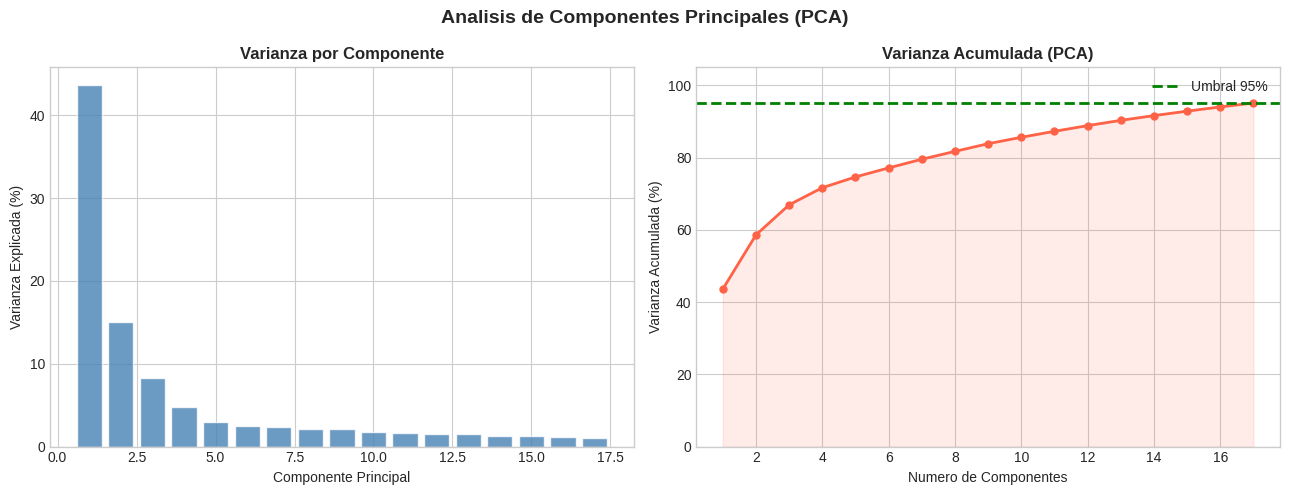

Resumen: 17 componentes retienen el 95% de la varianza informativa.
Dataset transformado listo para modelado.


In [ ]:
# Visualizacion de varianza explicada por PCA
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Analisis de Componentes Principales (PCA)',
             fontsize=14, fontweight='bold')

comp = range(1, n_comp + 1)
axes[0].bar(comp, var_ratio * 100, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Varianza por Componente', fontweight='bold')

axes[1].plot(comp, var_acum * 100, marker='o', color='tomato', linewidth=2, markersize=5)
axes[1].axhline(y=95, color='green', linestyle='--', linewidth=2, label='Umbral 95%')
axes[1].fill_between(comp, var_acum * 100, alpha=0.12, color='tomato')
axes[1].set_xlabel('Numero de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Acumulada (PCA)', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()

print(f'Resumen: {n_comp} componentes retienen el 95% de la varianza informativa.')
print('Dataset transformado listo para modelado.')

### ✏️ Pregunta 3

**¿Cuál es la diferencia entre normalización Min-Max y estandarización Z-score?
¿Cuándo usarías cada una?**

>**Respuesta:**
- **Min-Max** escala todos los valores al rango [0, 1]. Úsala cuando el algoritmo requiere ese rango (redes neuronales, KNN) y los datos no tienen outliers extremos.
- **Z-score** transforma a media=0 y std=1. Úsala cuando hay outliers moderados, cuando el algoritmo asume distribución normal (regresión, SVM) o cuando se aplica PCA, ya que PCA requiere variables en la misma escala con varianza comparable.

En este pipeline se usa Z-score porque se aplica PCA como paso final.

### ✏️ Pregunta 4

**¿Por qué es importante el parámetro `drop='first'` en One-Hot Encoding?
¿Qué problema evita?**

>**Respuesta:**
Evita la **trampa de la variable dummy** (multicolinealidad perfecta). Si una variable tiene k categorías y se crean k columnas, la última es combinación lineal exacta de las demás. Esto desestabiliza modelos lineales (regresión logística) porque la matriz de diseño se vuelve singular. Con drop='first' se eliminan k−1 columnas conservando toda la información sin redundancia.

## 🔷 Paso 8: Selección de atributos

*Ref: Müller, A. C. y Guido, S. (2016). Introduction to Machine Learning with Python. Cap. 3.*

**¿Qué hacemos?** Aplicamos **SelectKBest** con Información Mutua para identificar las
variables más relevantes para predecir churn. Trabajamos sobre los datos preprocesados
**del train** (sin PCA) para mantener la interpretabilidad por nombre de variable.

**¿Por qué Información Mutua?** A diferencia de la correlación de Pearson (solo lineal),
la Información Mutua captura dependencias **no lineales**, más apropiadas para datos de churn.

**Regla antidata leakage:** El selector se ajusta **solo sobre `X_train`**. Los scores
se calculan sin ver los datos del test en ningún momento.

**Impacto:** Identificar las variables más importantes guía la interpretación del modelo
y sirve como validación de que el Feature Engineering agregó información útil.

Total variables tras preprocesamiento (sin PCA): 35

TOP 10 VARIABLES MAS IMPORTANTES (Informacion Mutua con Churn):
Rank  Variable                                      Score
---------------------------------------------------------
1     tenure                                     0.073126
2     Contract_Two year                          0.056151
3     num_servicios                              0.052493
4     MonthlyCharges                             0.051792
5     tenure_group_Largo                         0.045276
6     InternetService_Fiber optic                0.044324
7     tenure_group_Nuevo                         0.042324
8     cargo_por_mes                              0.040627
9     TotalCharges                               0.038814
10    PaymentMethod_Electronic check             0.036350


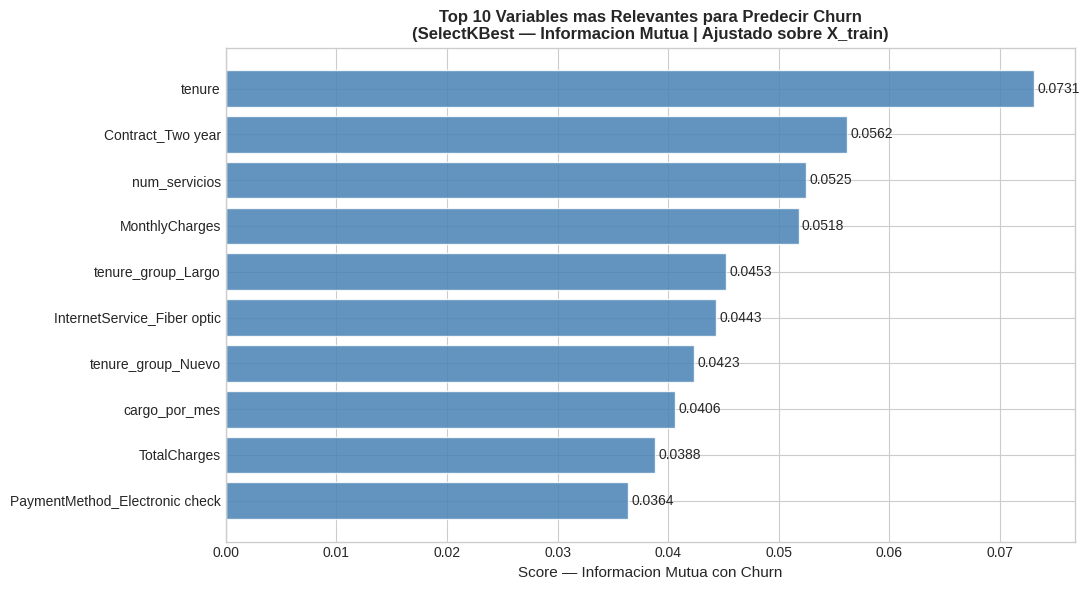

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Reutilizar el preprocesador ya ajustado (sin PCA) para datos interpretables
preprocesador_fit = pipeline_completo.named_steps['preprocesador']
X_train_enc = preprocesador_fit.transform(X_train)
X_test_enc  = preprocesador_fit.transform(X_test)

# Obtener nombres de columnas tras OneHotEncoder
cat_encoder   = preprocesador_fit.named_transformers_['cat']['encoder']
nombres_cat   = cat_encoder.get_feature_names_out(vars_categoricas)
todos_nombres = vars_numericas + list(nombres_cat)

print(f'Total variables tras preprocesamiento (sin PCA): {len(todos_nombres)}')

# SelectKBest — ajustado SOLO sobre X_train
selector = SelectKBest(score_func=mutual_info_classif, k=10)
selector.fit(X_train_enc, y_train)

scores_df = pd.DataFrame({
    'Variable': todos_nombres,
    'Score':    selector.scores_
}).sort_values('Score', ascending=False).reset_index(drop=True)

print('\nTOP 10 VARIABLES MAS IMPORTANTES (Informacion Mutua con Churn):')
print(f'{"Rank":<5} {"Variable":<40} {"Score":>10}')
print('-' * 57)
for i, row in scores_df.head(10).iterrows():
    print(f'{i+1:<5} {row["Variable"]:<40} {row["Score"]:>10.6f}')

# Visualizacion
fig, ax = plt.subplots(figsize=(11, 6))
top10 = scores_df.head(10)
ax.barh(top10['Variable'][::-1], top10['Score'][::-1],
        color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Score — Informacion Mutua con Churn', fontsize=11)
ax.set_title('Top 10 Variables mas Relevantes para Predecir Churn\n'
             '(SelectKBest — Informacion Mutua | Ajustado sobre X_train)',
             fontsize=12, fontweight='bold')
for bar, val in zip(ax.patches, top10['Score'][::-1]):
    ax.text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

### ✏️ Pregunta 6

**¿Cuáles son las 5 variables más importantes según SelectKBest?
¿Coinciden con los resultados del Lab 3?**

> **Respuesta:**

Las 5 variables más importantes según Información Mutua son:
1. tenure (0.0731)
2. Contract_Two year (0.0562)
3. num_servicios (0.0525)
4. MonthlyCharges (0.0518)
5. tenure_group_Largo (0.0453)

Sí coinciden en parte con el Lab 3: el tipo de contrato y la antigüedad del cliente son consistentemente los predictores más relevantes de churn. Además, num_servicios y cargo_por_mes, creados por Feature Engineering, aparecen en el top 10, confirmando que las nuevas variables aportaron información útil al modelo.

## 🔷 Paso 9: Reducción de dimensionalidad con PCA

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 2.*

El PCA ya fue aplicado como último paso del `pipeline_completo` en el Paso 7.
Los resultados están disponibles en `X_train_prep` y `X_test_prep`.

**Recordatorio de resultados:**
- PCA ajustado **exclusivamente sobre `X_train`** → sin Data Leakage.
- Se retiene el **95% de la varianza** con un número reducido de componentes.
- Esto reduce el ruido y el tiempo de entrenamiento sin perder información relevante.

### ✏️ Pregunta 7

**¿Cuántos componentes se necesitan para mantener el 95% de varianza?
¿Qué ventaja tiene PCA para el modelo?**

>**Respuesta:**
Se necesitan **17 componentes** (de 35 variables originales tras el preprocesamiento) para retener el 95.13% de la varianza. La ventaja es doble: (1) **reduce el ruido** eliminando componentes de baja varianza que podrían causar sobreajuste, y (2) **reduce el tiempo de entrenamiento** al disminuir la dimensionalidad. El costo es perder interpretabilidad directa de las variables originales.

## 🔷 Paso 10: Resumen del Pipeline completo

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 2.*

**¿Qué hacemos?** Verificamos que el pipeline completo funciona correctamente y mostramos
un resumen de su estructura y los datos listos para modelado.

In [ ]:
# Resumen del pipeline
print('PIPELINE COMPLETO:')
print(pipeline_completo)

print(f'\nDATOS LISTOS PARA MODELADO:')
print(f'  X_train_prep shape: {X_train_prep.shape}')
print(f'  X_test_prep  shape: {X_test_prep.shape}')
print(f'  y_train      shape: {y_train.shape}  | Churn rate: {y_train.mean():.3f}')
print(f'  y_test       shape: {y_test.shape}   | Churn rate: {y_test.mean():.3f}')
print('\nPipeline creado exitosamente. Listo para modelado.')
print('\nPara guardar el pipeline en produccion:')
print('  import joblib')
print('  joblib.dump(pipeline_completo, "pipeline_churn.pkl")')

PIPELINE COMPLETO:
Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'SeniorCitizen',
                                                   'num_servicios',
                                                   'cargo_por_mes']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                          

### ✏️ Pregunta 8

**¿Por qué es mejor usar un Pipeline que aplicar cada transformación por separado?**

>**Respuesta:** El Pipeline garantiza: (1) **sin data leakage**: los transformadores se ajustan solo con datos de entrenamiento y se aplican correctamente al test; (2) **reproducibilidad**: mismo orden y parámetros siempre; (3) **portabilidad**: se serializa con joblib para producción; (4) **compatibilidad con GridSearchCV** para optimizar hiperparámetros de todo el flujo en una sola llamada. Aplicar transformaciones separadas es propenso a errores de orden y leakage accidental.

---
# ACTIVIDAD 3: Caso de Estudio — Pipeline para modelo de Churn

> **Contexto:** El equipo de Data Science de TelcoPerú necesita preparar el dataset para
> entrenar un modelo predictivo de churn. Documenta y justifica cada decisión del pipeline.

### ✏️ Pregunta A

**Describe las etapas del pipeline que aplicaste. ¿En qué orden se ejecutan y por qué ese orden es el correcto?**

> **Respuesta:**

El pipeline se ejecuta en este orden obligatorio:

1. **Imputación** (SimpleImputer): primero, porque los pasos posteriores no toleran valores nulos.
2. **Escalado** (StandardScaler): después de imputar, para que todos los valores sean comparables y PCA funcione correctamente.
3. **Codificación** (OneHotEncoder): convierte categóricas a numéricas, necesario antes de PCA.
4. **Reducción de dimensionalidad** (PCA): al final del preprocesamiento, después de escalar, para que los componentes sean matemáticamente válidos.
5. **Modelado**: recibe datos limpios, escalados y reducidos.

El orden es crítico: escalar antes de imputar generaría errores; aplicar PCA antes de escalar produciría componentes sin sentido.

### ✏️ Pregunta B

**¿Qué es el Data Leakage y cómo lo evitas al dividir el dataset en train/test antes de normalizar?**

>**Respuesta:**
**Data Leakage** ocurre cuando información del conjunto de prueba contamina el entrenamiento, generando métricas infladas que no se replican en producción. Se evita: (1) dividiendo train/test **antes** de cualquier transformación; (2) llamando `.fit()` o `.fit_transform()` **solo sobre X_train** para que el scaler, imputer y PCA aprendan únicamente de los datos de entrenamiento; (3) aplicando solo `.transform()` sobre X_test con los parámetros aprendidos del train. El Pipeline de scikit-learn garantiza esto automáticamente.

### ✏️ Pregunta C

**Compara SelectKBest con PCA. ¿En qué situaciones preferirías cada técnica?**

>**Respuesta:**

- **SelectKBest** conserva variables originales e interpretables. Preferible cuando se necesita explicar qué variables impactan el churn (reportes de negocio, cumplimiento regulatorio, comunicación con stakeholders no técnicos).

- **PCA** crea componentes abstractos combinando todas las variables. Preferible cuando hay alta correlación entre variables y el objetivo es maximizar rendimiento predictivo sin importar la interpretabilidad, o cuando se necesita reducir significativamente la dimensionalidad para modelos sensibles a la maldición de la dimensionalidad.

### ✏️ Pregunta D

**¿Qué variables nuevas creaste mediante Feature Engineering? ¿Por qué son útiles para predecir churn?**

>**Respuesta:**

Se crearon 3 variables:

- **tenure_group**: discretiza la antigüedad en Nuevo/Corto/Medio/Largo. Captura la relación no lineal entre antigüedad y churn: clientes "Nuevo" tienen tasa de churn de 47.4%, los "Largo" solo 9.5%.
- **num_servicios**: suma de servicios contratados. Mayor número = mayor switching cost = menor churn. Aparece 3.° en importancia según SelectKBest.
- **cargo_por_mes**: TotalCharges / (tenure+1). Identifica clientes que pagaban más en el pasado, señal de posible insatisfacción por incrementos de precio.

Las tres aparecen en el top 10 de variables más relevantes, confirmando su valor predictivo.

### ✏️ Pregunta E

**Si aplicaras este pipeline a 1 millón de clientes nuevos cada mes, ¿cómo garantizarías la reproducibilidad?**

>**Respuesta:**

1. **Serializar el pipeline** con `joblib.dump()` tras el entrenamiento, asegurando que los mismos parámetros (medias, escalas, componentes PCA, categorías OHE) se apliquen en producción sin reentrenar.
2. **Control de versiones** del pipeline y datos de entrenamiento con MLflow o DVC para trazabilidad completa.
3. **Monitoreo de data drift** mensual: verificar que las distribuciones de los nuevos clientes no hayan cambiado significativamente respecto al train original (usando métricas como PSI o KL divergence). Si hay drift, reentrenar el pipeline.

---
# 📝 CONCLUSIONES

1. La preparación de datos es la etapa más determinante del ciclo CRISP-DM: un pipeline bien construido con imputación, codificación, escalado y PCA garantiza modelos robustos, libres de data leakage y reproducibles en producción.

2. El Feature Engineering aportó variables (num_servicios, cargo_por_mes, tenure_group) que aparecen en el top 10 de importancia según SelectKBest, demostrando que el conocimiento del negocio es tan valioso como las técnicas estadísticas.

3. Usar un Pipeline formal de scikit-learn no solo evita errores manuales y data leakage, sino que permite serializar y desplegar el flujo completo de preparación en producción con un solo objeto, garantizando que nuevos datos sean procesados exactamente igual que los datos de entrenamiento.

---

## 📚 Referencias

- Géron, A. (2022). *Hands-On Machine Learning* (3.ª ed.). O'Reilly Media.
- Gironés Roig, J. et al. (2017). *Minería de datos: modelos y algoritmos*. Editorial UOC.
- Ilyas, I. F. y Chu, X. (2019). *Cleaning Data for Data Science*. ACM.
- Müller, A. C. y Guido, S. (2016). *Introduction to Machine Learning with Python*. O'Reilly Media.

---
*Minería de Datos — Semana 4 | TECSUP 2026-I | Prof. Pilar Rocío Sayán Mejía*